# All-sky analysis plots

This notebook reproduces all figures related to the visible channel analysis under all-sky conditions.


## Import libraries and data

**Remarks:**
 - Update the paths in the notebook to point to your local clone of the `RTTOV_AROME` repository.
 - Also update the paths inside `RTTOV_AROME/read_output_data/results_vis_all_sky_a1/` to where your `data_out` directory is located.
 - Additional required changes are documented in the script's docstring.


In [ ]:
import sys

sys.path.append("/path/to/RTTOV_AROME")
sys.path.append("/path/to/.local/lib/python3.8/site-packages")
sys.path.append("/path/to/RTTOV_AROME/read_output_data")
sys.path.append("/path/to/RTTOV_AROME/plot_results")

from results_vis_all_sky_a1 import *
from utils1 import *
from utils2 import *

# Used to mask data points beyond the AROME model domain
domain_mask = np.load("/path/to/RTTOV_AROME/masks/AROME_Mask.npy")

In [ ]:
# Read the Elevation height
import pygrib
sys.path.append("/path/to/RTTOV_AROME/run_rttov")
from visir_profiles_arome import *
from visir_obs_utils import map_to_sat_grid_edited
grbs = []
grb_path = f"/path/to/arome_forecasts/august23/day_01/20230801_12_0003.grb"
tmp = pygrib.open(grb_path)
grbs.append(tmp)
z_surface = get_profile(grbs, 0, 8, "surface", plot_par = False)
terrain, _ = map_to_sat_grid_edited(z_surface.data[0,:,:], channel='', varname='refl', plot_only_latlon=False, 
                                    vmin=None, vmax=None, cmap=None, save_tile=False, dbg=False, repo_path='/path/to/')
H = (terrain*domain_mask)/1000

latlon2xy constants  0.731991592560469 1.836504601854703 1.0103403109190163
misses in latlon2tri_exact_exec:  57644


## Maps

In [ ]:
hour = '120000'
out_1 = exp_results['default']["O"]["20230805_120000"]
out_2 = exp_results['default']["B-rttov12"]["20230805_120000"]
out_3 = exp_results['default']["B-rttov13"]["20230805_120000"]

geo_map_vis([out_1, out_2, out_3], ["O", "B (v12)", "B (v13)"], cmaps=["cubehelix", "cubehelix", "cubehelix"],
            date="", unit="R []",
            lon=rttov122["default"].data.lon_obs_map.values, 
            lat=rttov122["default"].data.lat_obs_map.values,
            vmin=0, vmax=1,save=True,shrink=0.2,
            out_path='/path/to/to_ucloud/',
            name='R_all_sky_20230805_120000'
            )

## Histograms

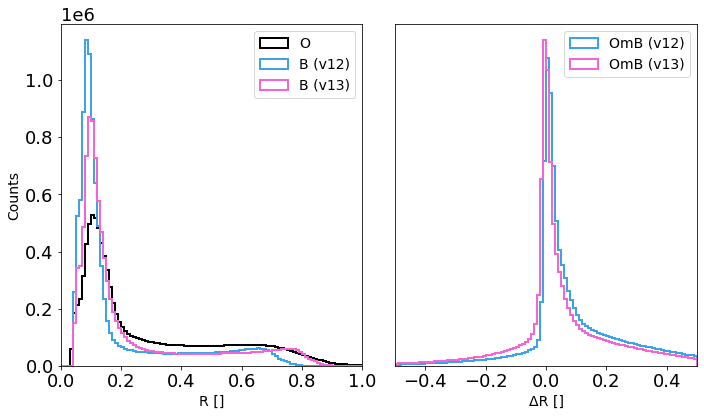

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = 100
range_ = (0, 1.0)
log_scale = False

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.rcParams.update({"font.size":14})
fig.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.0, hspace=0.0)

axs = axs.flatten()  # makes indexing easier

# first plot
axs[0].hist(flatten_array(ref["O"]), bins=100, 
              log=log_scale,histtype='step', color = 'black',range= range_, lw=2, label = 'O');
axs[0].hist(flatten_array(ref["B-rttov12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'B (v12)');
axs[0].hist(flatten_array(ref["B-rttov13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'B (v13)');
axs[0].set_title("", fontsize=14)
axs[0].set_xlabel("R []", fontsize=14)
axs[0].set_xlim(0,1)
axs[0].set_ylabel("Counts", fontsize=14)
axs[0].legend(fontsize=14)

bins = 100
range_ = (-0.5, 0.5)
log_scale = False

# second plot
axs[1].hist(flatten_array(ref["OmB-12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'OmB (v12)');
axs[1].hist(flatten_array(ref["OmB-13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'OmB (v13)');
axs[1].set_title("", fontsize=14)
axs[1].set_xlabel("ΔR []", fontsize=14)
axs[1].yaxis.set_visible(False)
axs[1].set_xlim(-0.5, 0.5)
axs[1].legend(fontsize=14)

plt.tight_layout()
plt.savefig("/path/to/to_ucloud/R_hist_all_sky_12utc.png", dpi=300)
plt.show()

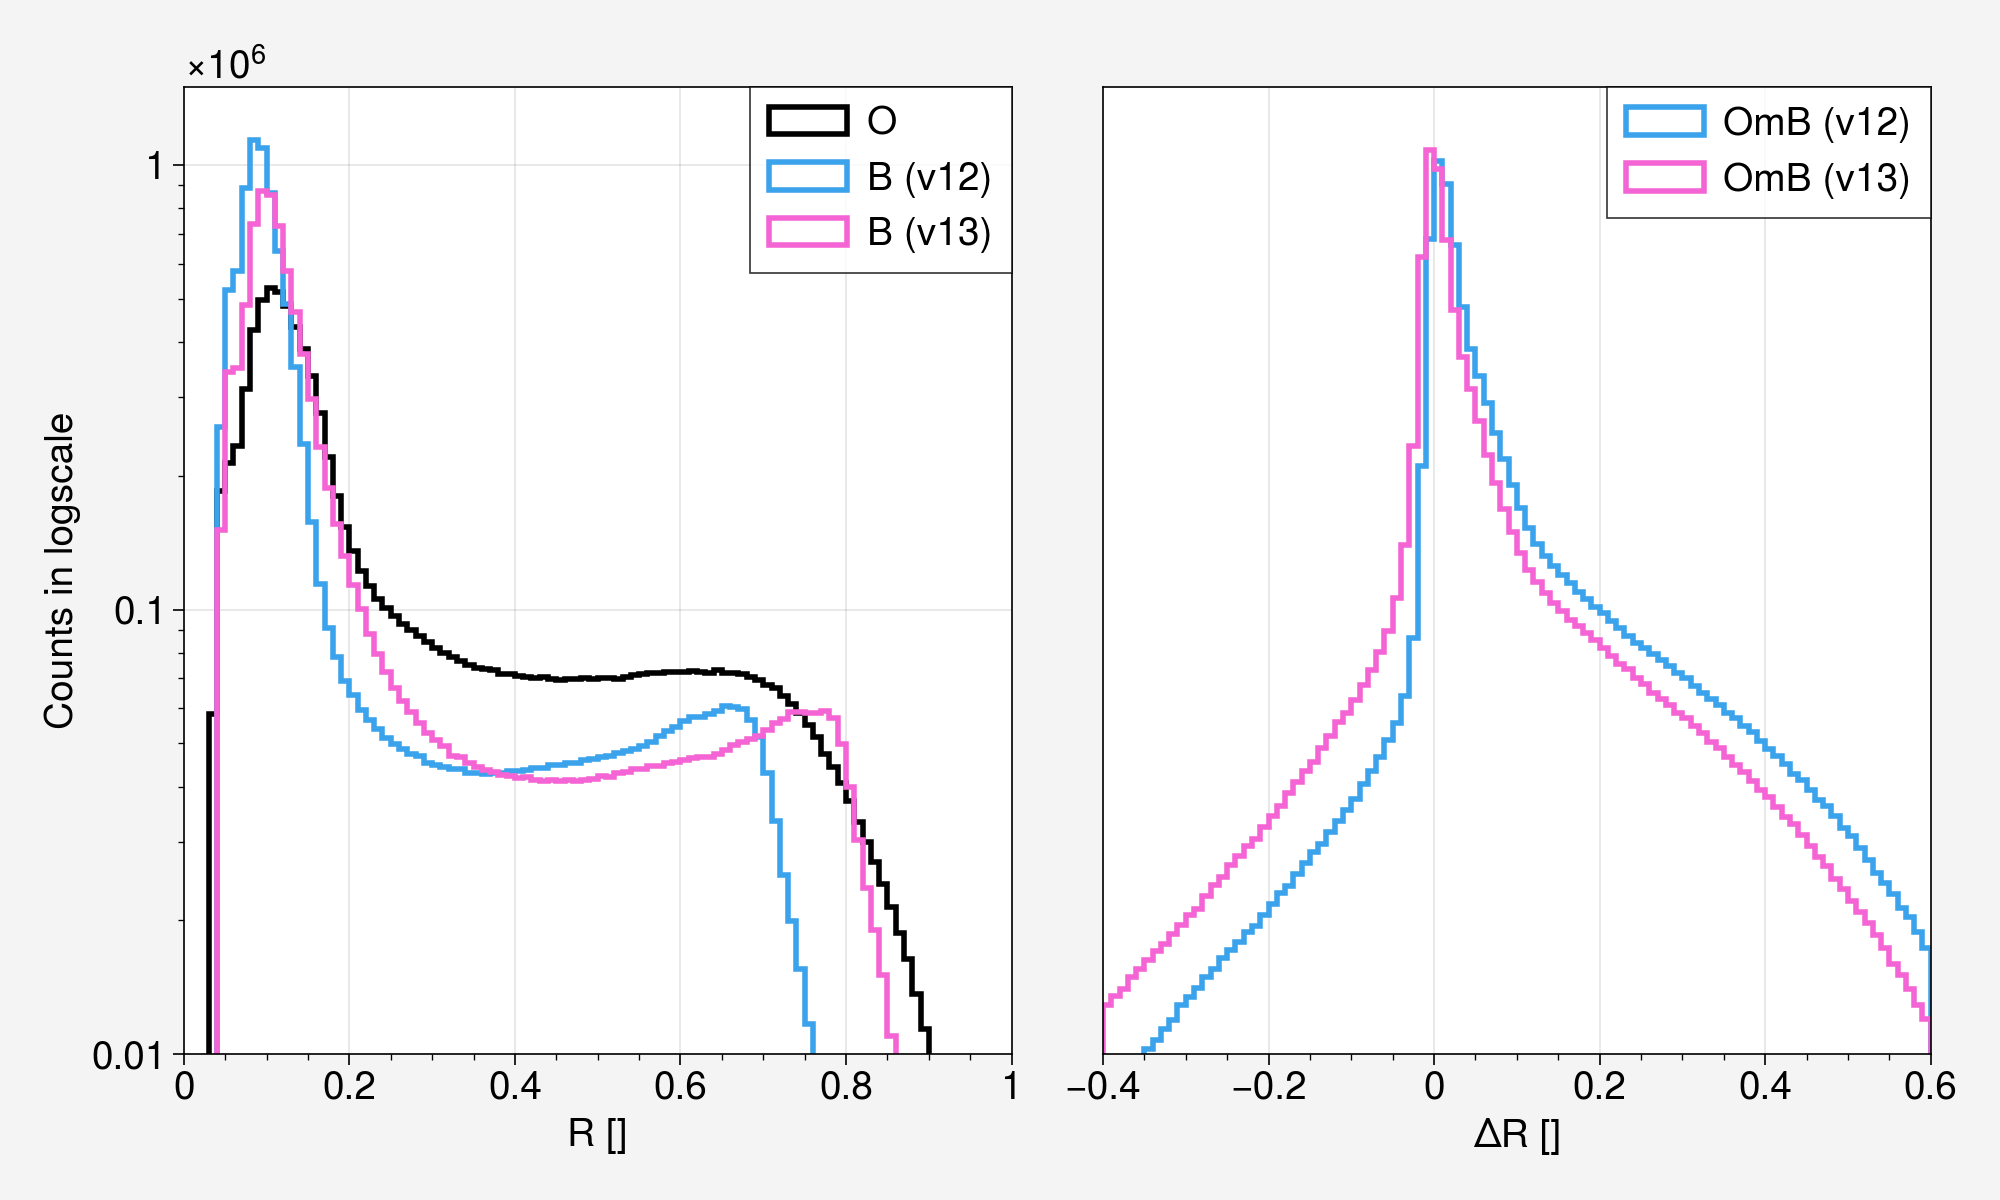

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = 100
range_ = (0, 1.0)
log_scale = True

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.rcParams.update({"font.size":14})
fig.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.0, hspace=0.0)

axs = axs.flatten()  # makes indexing easier

# first plot
axs[0].hist(flatten_array(ref["O"]), bins=100, 
              log=log_scale,histtype='step', color = 'black',range= range_, lw=2, label = 'O');
axs[0].hist(flatten_array(ref["B-rttov12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'B (v12)');
axs[0].hist(flatten_array(ref["B-rttov13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'B (v13)');
axs[0].set_title("", fontsize=14)
axs[0].set_xlabel("R []", fontsize=14)
axs[0].set_xlim(0,1)
axs[0].set_ylim(1e4,1.5e6)
axs[0].set_ylabel("Counts in logscale", fontsize=14)
axs[0].legend(fontsize=14)

bins = 100
range_ = (-0.4, 0.6)
log_scale = True

# second plot
axs[1].hist(flatten_array(ref["OmB-12"]), bins=100, 
              log=log_scale,histtype='step', color = '#3ba3ec',range= range_, lw=2, label = 'OmB (v12)');
axs[1].hist(flatten_array(ref["OmB-13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'OmB (v13)');
axs[1].set_title("", fontsize=14)
axs[1].set_xlabel("ΔR []", fontsize=14)
axs[1].yaxis.set_visible(False)
axs[1].set_xlim(-0.4, 0.6)
axs[1].set_ylim(1e4,1.5e6)
axs[1].legend(fontsize=14)

plt.tight_layout()
plt.savefig("/path/to/to_ucloud/R_hist_all_sky_12utc.png", dpi=300)
plt.show()

## Sensitivity to spatial resolution

### Point spread function (PSF)

The option is only available with the visop operator

In [21]:
L_visop = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [22]:
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims_psf = pd.DataFrame()
sims_psf["O"] = flatten_array(O(visop['default'], datetime_slice))
sims_psf["B-psf=off"] = flatten_array(L_visop(visop['default'], datetime_slice))
sims_psf["B-psf=on"] = flatten_array(L_visop(visop['v2'], datetime_slice))

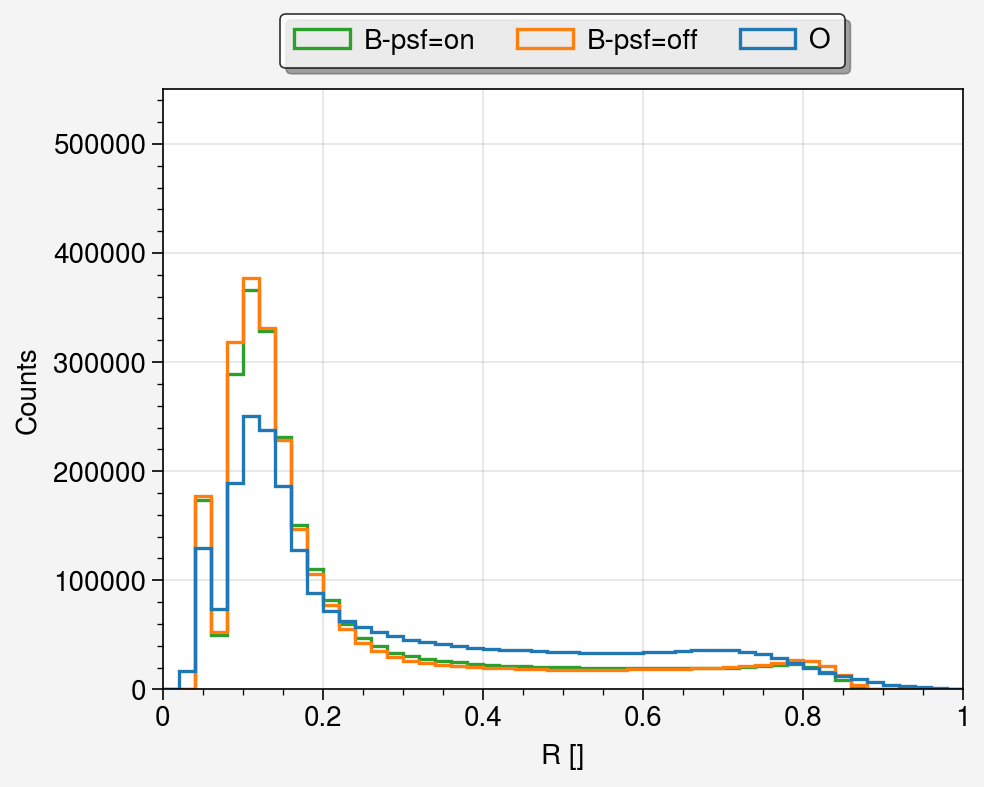

In [ ]:
fig, ax = plot_simulations(sims_psf,x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=True, name="/path/to/to_ucloud/psf_results")

### Superobbing

In [3]:
superob = True
if superob:
    grid_sizes = {"S6": (2,1), "S12": (4,2), "S18":(6,3),"S36":(12,6)}
    keys_to_process = ["O", "rttov12-default", "rttov13-default"]
    exp_keys = {
        "O": "O",
        "rttov12-default": "B-rttov12",
        "rttov13-default": "B-rttov13"
    }

    superobbed_results = {key: {size: {} for size in grid_sizes} for key in keys_to_process}
    flattened_results = {key: {size: None for size in grid_sizes} for key in keys_to_process}

    for date_time in datetime_slice:
        for key in keys_to_process:
            for size, window in grid_sizes.items():
                # Perform superobbing
                input_data = exp_results['default'][exp_keys[key]][date_time]
                tmp_data = superobbing(input_data, window[0], window[1])
                superobbed_results[key][size][date_time] = tmp_data

    # Flatten all 2D arrays for all datetime slices into a single 1D array
    for key in keys_to_process:
        for size in grid_sizes:
            all_flattened = [
                superobbed_results[key][size][date_time].ravel()
                for date_time in datetime_slice
            ]
            flattened_results[key][size] = np.concatenate(all_flattened)

    if True: # distribution statistics
        data_list = []
        # Native resolution stats
        for o, b12, b13 in zip(
            visop['default'].all_sky_observed,
            rttov122['default'].all_sky_synthetic,
            rttov132['default'].all_sky_synthetic
        ):
            data_list.append({"O": o, "OmB (v12)": o - b12 ,"B (v12)": b12, "B (v13)": b13, "OmB (v13)": o - b13, "size": "N-S"})

        # Superobbed stats
        for size in grid_sizes:
            O_values = flattened_results["O"][size]
            B12_values = flattened_results["rttov12-default"][size]
            B13_values = flattened_results["rttov13-default"][size]
            OmB12_values = O_values - B12_values
            OmB13_values = O_values - B13_values

            for o, omb12, b12, b13, omb13 in zip(O_values, OmB12_values, B12_values, B13_values, OmB13_values):
                data_list.append({"O": o, "OmB (v12)": omb12, "B (v12)": b12, "B (v13)": b13, "OmB (v13)": omb13, "size": size})

        all_data = pd.DataFrame(data_list)
        all_data = all_data.dropna()

In [ ]:
all_data.to_csv('/path/to/out.csv', index=False)

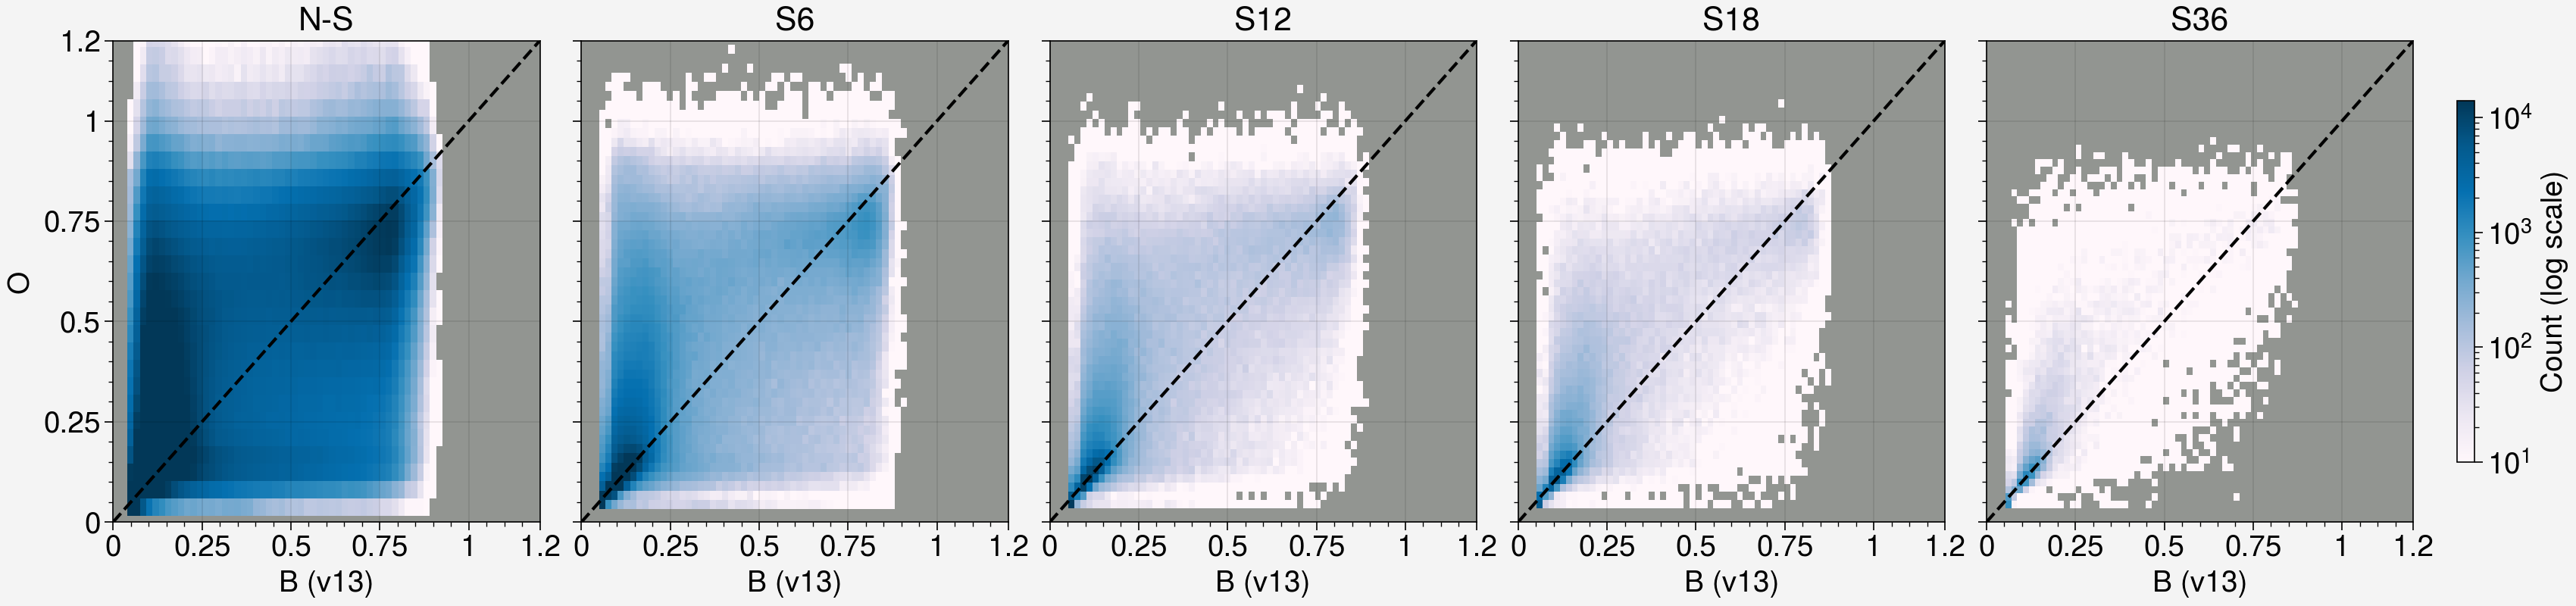

In [ ]:
# Variables to plot
x_var = 'B (v13)'
y_var = 'O'
size_categories = ['N-S', 'S6', 'S12', 'S18', 'S36']

# Log‐norm for your 2D histograms
norm = LogNorm(vmin=10, vmax=14000)
cmap = sns.color_palette("PuBu", as_cmap=True)

# Make a 1×5 grid, one panel per size
fig, axes = plt.subplots(nrows=1, ncols=len(size_categories),
                         figsize=(17, 4), constrained_layout=True)
plt.rcParams.update({'font.size': 14})
for idx, size in enumerate(size_categories):
    ax = axes[idx]
    subset = all_data[all_data['size'] == size]
    x = subset[x_var]
    y = subset[y_var]

    # 2D‐histogram → masked array so zeros are transparent
    hist, xedges, yedges = np.histogram2d(x, y, bins=50)
    hist_masked = np.ma.masked_where(hist == 0, hist)

    im = ax.imshow(
        hist_masked.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap=cmap,
        norm=norm,
        aspect='auto'
    )

    # y = x line
    ax.plot([0, 1.2], [0, 1.2], color='black', linestyle='--', linewidth=1.5)

    # axis limits
    major_ticks= [0, 0.25, 0.5, 0.75, 1,1.2]
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    
    # labels & title
    ax.set_xlabel(x_var)
    if idx == 0:
        ax.set_ylabel(y_var)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(f"{size}")
    ax.set_facecolor('xkcd:grey')
# single colorbar on the right
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    location='right',
    shrink=0.75,pad=0.01,
    label=f'Count (log scale)'
)

plt.savefig("/path/to/to_ucloud/hist_B_(v13)_vs_O.png", dpi=300)
plt.show()

In [36]:
all_data

,O,OmB (v12),B (v12),B (v13),OmB (v13),size
2586,0.068115,0.005895,0.062220,0.070924,-0.002809,N-S
2587,0.065422,0.001843,0.063579,0.072453,-0.007031,N-S
2588,0.065349,-0.003025,0.068374,0.077825,-0.012477,N-S
2589,0.086164,0.006422,0.079742,0.090565,-0.004402,N-S
2590,0.101716,0.021939,0.079777,0.090602,0.011114,N-S
...,...,...,...,...,...,...
16643040,0.786955,0.479182,0.307773,0.385804,0.401151,S36
16643041,0.576205,0.410714,0.165491,0.233371,0.342834,S36
16643042,0.450832,0.293923,0.156909,0.220408,0.230424,S36
16643043,0.323226,0.178196,0.145030,0.206371,0.116855,S36


In [9]:
size = ['N-S', "S6", "S12", "S18", "S36"]
for s in size:
    x = all_data[all_data['size'] == s]
    mean = np.mean(x["OmB (v13)"])
    std = np.std(x["OmB (v13)"])
    print(mean, std)

0.05868586998128281 0.18595671092768837
0.06515295691033782 0.17823283621740799
0.06444334547278086 0.1633017965998847
0.06415362588654126 0.15241579339393818
0.06303315590527288 0.13193645195926984


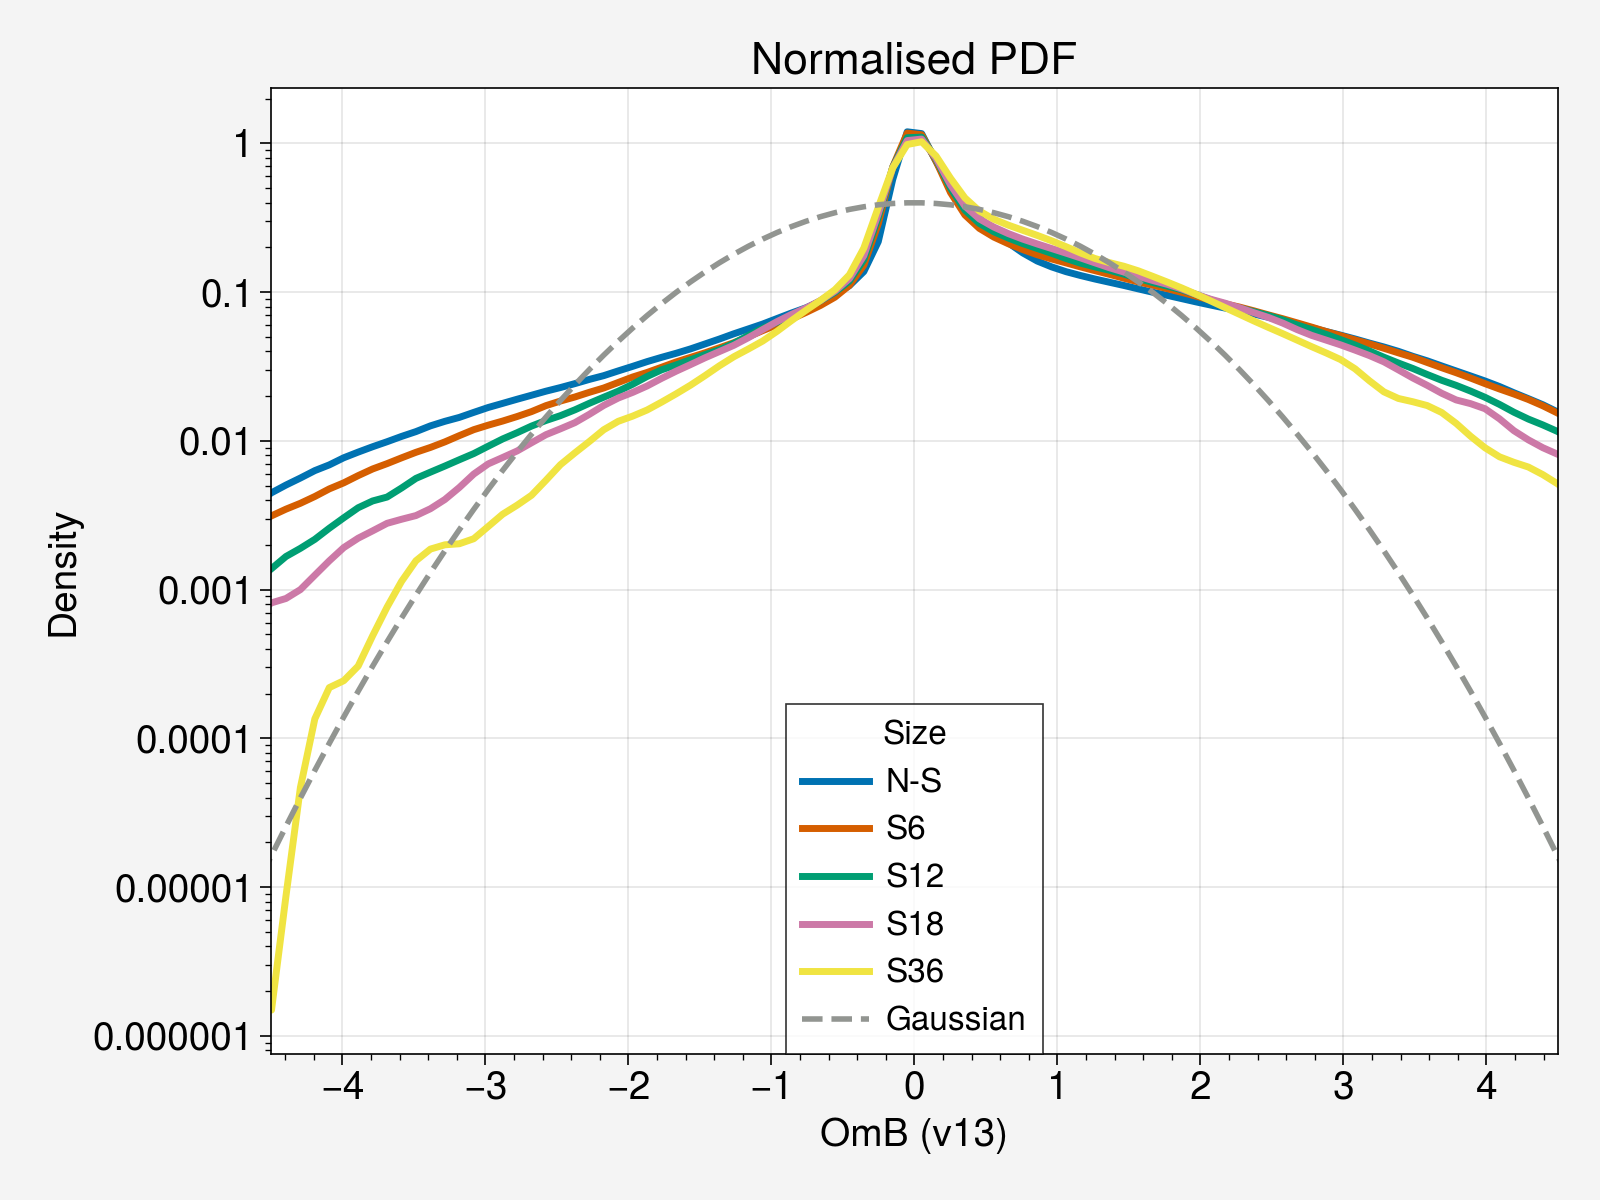

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

def plot_density_by_size(df: pd.DataFrame, sizes: list, variable: str, std: float, title: str = None):
    """
    Overplots normalized KDEs of `variable` for each category in `sizes`,
    plus the standard normal PDF for reference.

    Args:
        df (pd.DataFrame): Must contain columns 'size' and `variable`.
        sizes (list of str): The distinct size categories to plot.
        variable (str): Name of the numeric column to KDE.
        title (str, optional): Plot title.

    Returns:
        matplotlib.figure.Figure: The resulting figure.
    """
    # Prepare figure
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # Build a common x-grid from the full data range
    all_vals = pd.to_numeric(df[variable], errors='coerce').dropna()
    #x_min, x_max = all_vals.min(), all_vals.max()
    x_grid = np.linspace(-5, 5, 100)

    # Plot KDE for each size
    for i, size in enumerate(sizes):
        subset = df.loc[df['size'] == size, variable]
        vals = pd.to_numeric(subset, errors='coerce').dropna().values
        vals = vals/std
        if vals.size == 0:
            print(f"Warning: no data for size '{size}'")
            continue

        kde = gaussian_kde(vals)
        density = kde(x_grid)
        # Normalize so area=1 (gaussian_kde already does this)
        ax.plot(x_grid, density,
                label=size,
                color=colors[i % len(colors)],
                linewidth=2.5)

    # Overlay standard normal PDF (μ=0, σ=1)
    normal_pdf = norm.pdf(x_grid, loc=0, scale=1)
    ax.plot(x_grid, normal_pdf,
            linestyle='--',
            color='gray',
            linewidth=2,
            label='Gaussian')
    ax.set_yscale('log')
    # Final styling
    ax.set_xlim(-4.5,4.5)
    ax.set_xlabel(variable, fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    if title:
        ax.set_title(title, fontsize=16)
    ax.legend(title='Size', fontsize=12, title_fontsize=12)
    plt.tight_layout()

    return fig

# Example:
fig = plot_density_by_size(
     all_data,
     ['N-S','S6','S12','S18','S36'],
     'OmB (v13)',std,
     title='Normalised PDF'
)
plt.show()

In [ ]:
fig.savefig("/path/to/to_ucloud/density_logscale.png")

In [ ]:
fig.savefig("/path/to/to_ucloud/density.png")

## Sensitivity to snow

In [16]:
L = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y, sky_condition='all_sky')
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [17]:
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims_snow = pd.DataFrame()
sims_snow["O"] = flatten_array(O(visop['default'], datetime_slice))
sims_snow["B-12-default"] = flatten_array(L(rttov122['default'], datetime_slice))
sims_snow["B-12-10%"] = flatten_array(L(rttov122['v1'], datetime_slice)) 
sims_snow["B-12-20%"] = flatten_array(L(rttov122['v1.1'], datetime_slice))
sims_snow["B-12-100%"] = flatten_array(L(rttov122['v1.2'], datetime_slice))
sims_snow["B-13-default"] = flatten_array(L(rttov132['default'], datetime_slice))
sims_snow["B-13-10%"] = flatten_array(L(rttov132['v1'], datetime_slice))
sims_snow["B-13-100%"] = flatten_array(L(rttov132['v1.2'], datetime_slice))

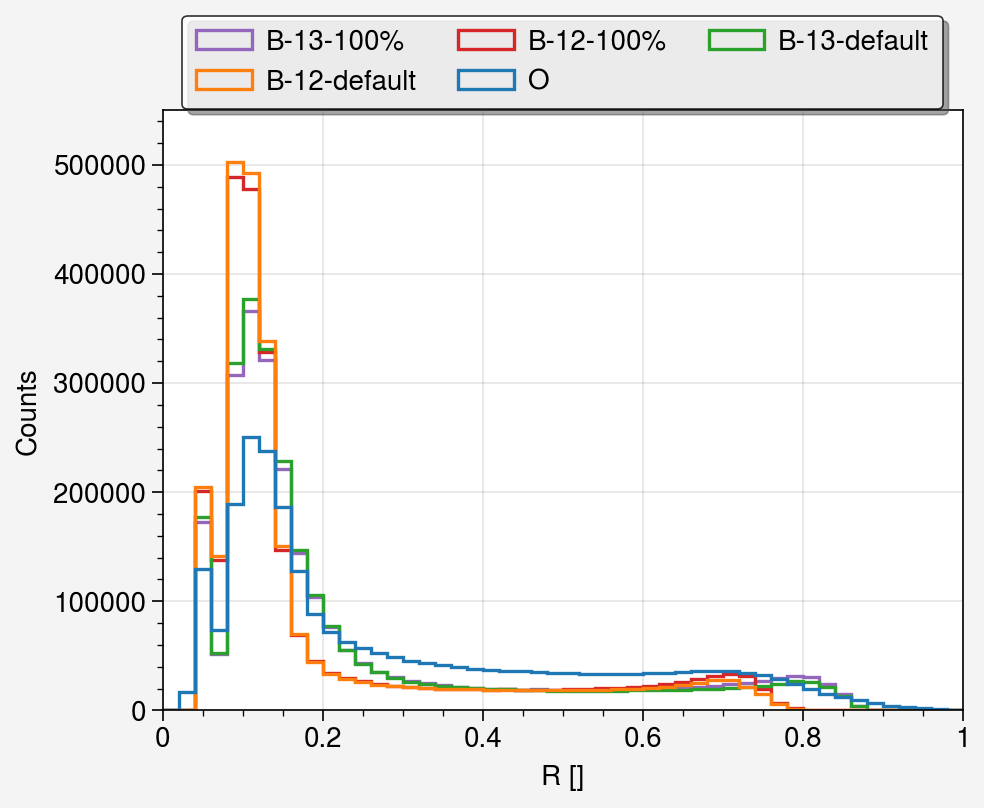

In [ ]:
fig, ax = plot_simulations(sims_snow,columns=["O", "B-12-default","B-13-default", "B-12-100%", "B-13-100%"],x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=True, name="/path/to/to_ucloud/results_snow")

In [26]:
LON = rttov122["default"].data.lon_obs_map.values
LAT = rttov122["default"].data.lat_obs_map.values

date_time = "20230805_120000"
o = exp_results['default']["O"][date_time]
b13_0 = exp_results['default']["B-rttov13"][date_time]
b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

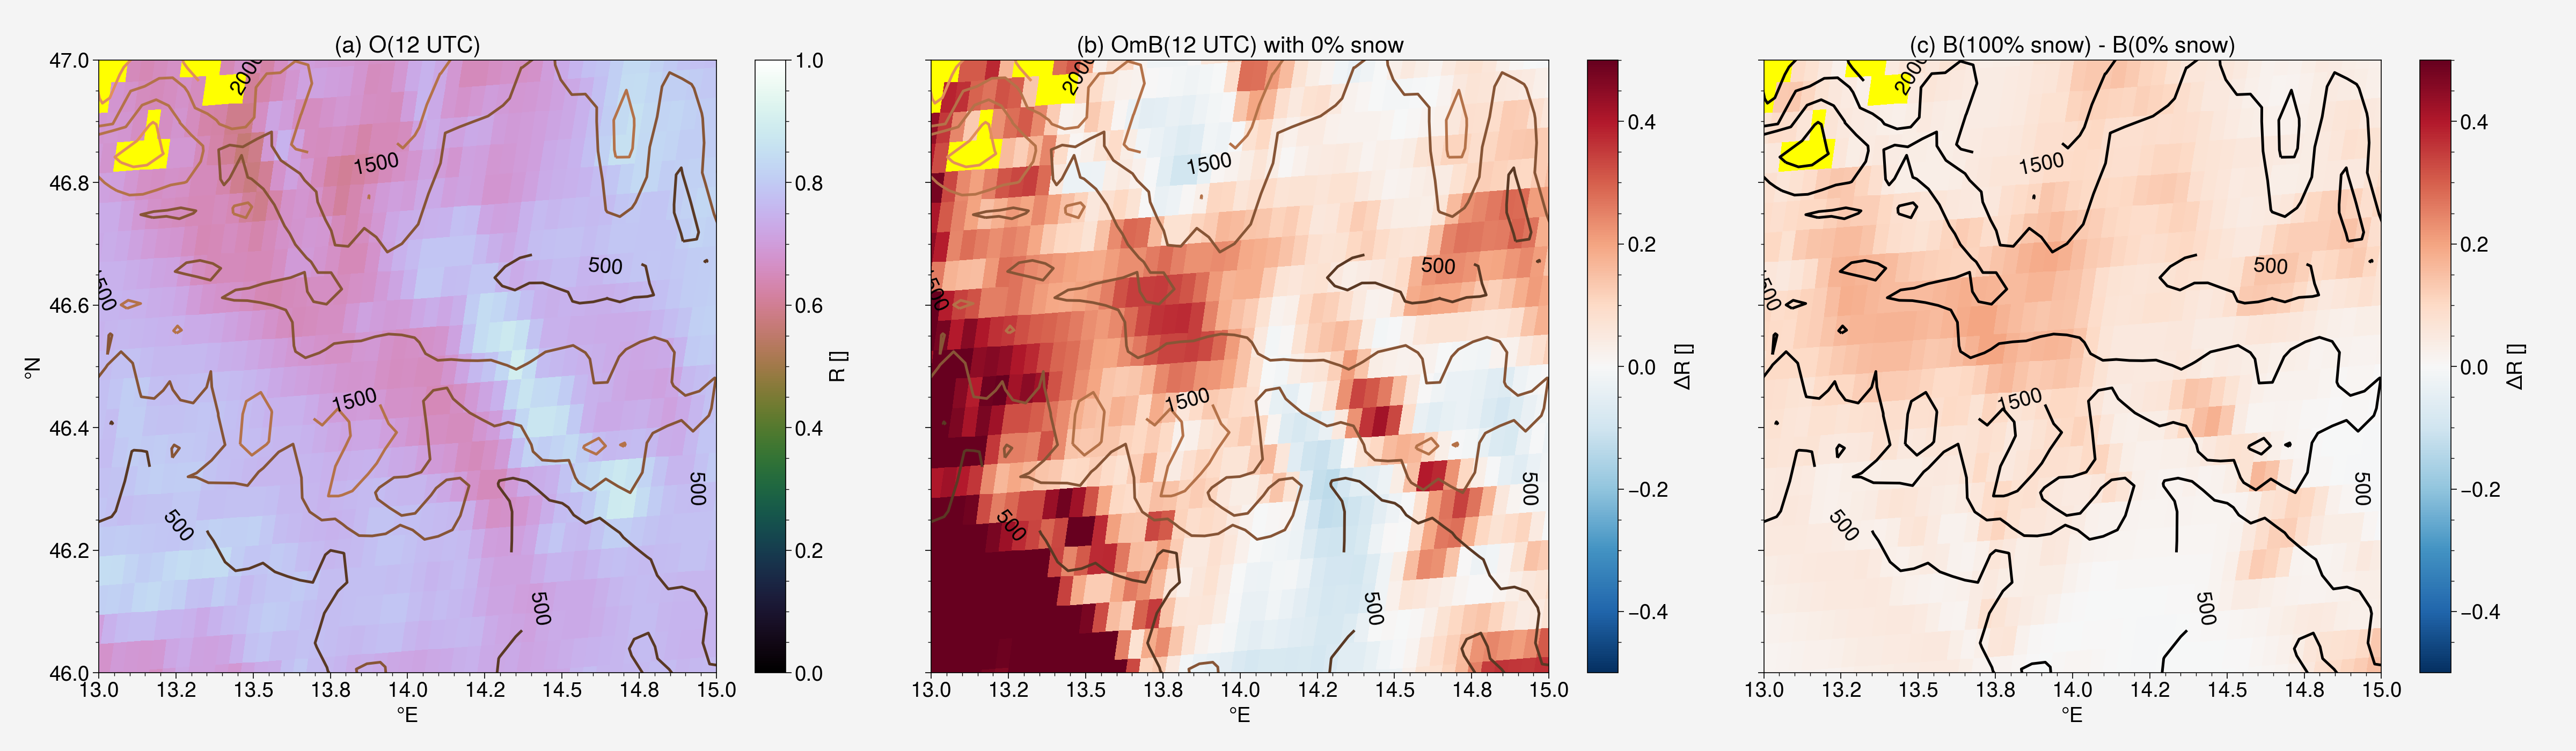

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- your existing slice and data prep ---
r1, r2 = 80, 150
c1, c2 = 240, 300
x = LON[r1:r2, c1:c2]
y = LAT[r1:r2, c1:c2]
z_terrain = H[r1:r2, c1:c2] * 1000

p1 = o[r1:r2, c1:c2]
p2 = o[r1:r2, c1:c2] - b13_0[r1:r2, c1:c2]
p3 = b13_100[r1:r2, c1:c2] - b13_0[r1:r2, c1:c2]

# --- create a 1×3 figure ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
plt.rcParams.update({'font.size': 14})

# common formatter for lon/lat
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.set_xlim(13, 15)
    ax.set_ylim(46, 47)
    ax.set_xlabel("°E")
axes[0].set_ylabel("°N")

# --- panel 1: O difference ---
pcm1 = axes[0].pcolormesh(x, y, p1,
                          vmin=0, vmax=1,
                          cmap='cubehelix', shading='auto')
cbar1 = fig.colorbar(pcm1, ax=axes[0], label="R []")
cont1 = axes[0].contour(x, y, z_terrain,
                       levels=5, cmap="copper", linewidths=1.8)
axes[0].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[0].set_title("(a) O(12 UTC)")
axes[0].set_facecolor('yellow')
# --- panel 2: B difference ---
pcm2 = axes[1].pcolormesh(x, y, p2,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm2, ax=axes[1], label="ΔR []")
cont2 = axes[1].contour(x, y, z_terrain,
                       levels=5, cmap="copper",linewidths=1.8)
axes[1].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[1].set_title("(b) OmB(12 UTC) with 0% snow")
axes[1].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm3 = axes[2].pcolormesh(x, y, p3,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar3 = fig.colorbar(pcm3, ax=axes[2], label="ΔR []")
cont3 = axes[2].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[2].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[2].set_title("(c) B(100% snow) - B(0% snow)")
axes[2].set_facecolor('yellow')
# --- layout & save ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("/path/to/to_ucloud/snow_effects.png", dpi=1200)
plt.show()

## Sensitivity to cloud condensation nuclei

In [18]:
L = lambda X, Y, d1=M1, d2=M: (
    X.data
     .synthetic_reflectance_VIS006
     .sel(datetimes=Y, sky_condition='all_sky')
     .values
    * d1 * d2
)
O = lambda X, Y, d1=M1, d2=M: (
    X.data
     .observed_reflectance_VIS006
     .sel(datetimes=Y)
     .values
    * d1* d2
)

In [19]:
#datetime_slice = "20230805_120000"
datetime_slice = list(f"202308{x:02d}_{hours[2]}" for x in range(1,32))
sims = pd.DataFrame()
sims["O"] = flatten_array(O(visop['default'], datetime_slice))
sims["B-12-default"] = flatten_array(L(rttov122['default'], datetime_slice))
sims["B-12-CCN_3.1"] = flatten_array(L(rttov122['v3.1'], datetime_slice)) 
sims["B-12-CCN_3.2"] = flatten_array(L(rttov122['v3.2'], datetime_slice))
sims["B-12-CCN_3.3"] = flatten_array(L(rttov122['v3.3'], datetime_slice))
sims["B-12-OPAC"] = flatten_array(L(rttov122['v4'], datetime_slice))
sims["B-13-default"] = flatten_array(L(rttov132['default'], datetime_slice))
sims["B-13-CCN_3.1"] = flatten_array(L(rttov132['v3.1'], datetime_slice)) 
sims["B-13-CCN_3.2"] = flatten_array(L(rttov132['v3.2'], datetime_slice))
sims["B-13-CCN_3.3"] = flatten_array(L(rttov132['v3.3'], datetime_slice))

In [12]:
L = (sims["B-13-CCN_3.3"]-sims["B-13-default"])*100/sims["B-13-default"]
print(f"min/max/mean {np.min(L)}/{np.max(L)}/{np.mean(L)}")
L = (sims["B-12-CCN_3.3"]-sims["B-12-default"])*100/sims["B-12-default"]
print(f"min/max/mean {np.min(L)}/{np.max(L)}/{np.mean(L)}")

min/max/mean 0.0/18.63665084718697/1.7926444523989216
min/max/mean 0.0/21.44198596313884/1.656998140441265


### Error statistics

In [4]:
import numpy as np
import pandas as pd

# Sample data
# Each column represents a distribution
data = OmB
data.columns.name = ''
data.name = 'OmB'

# Calculate error data
# Passed to 'errdata' in the 3rd subplot example
means = data.mean(axis=0)
means.name = data.name  # copy name for formatting
fadedata = np.percentile(data, (5, 95), axis=0)  # light shading
shadedata = np.percentile(data, (25, 75), axis=0)  # dark shading

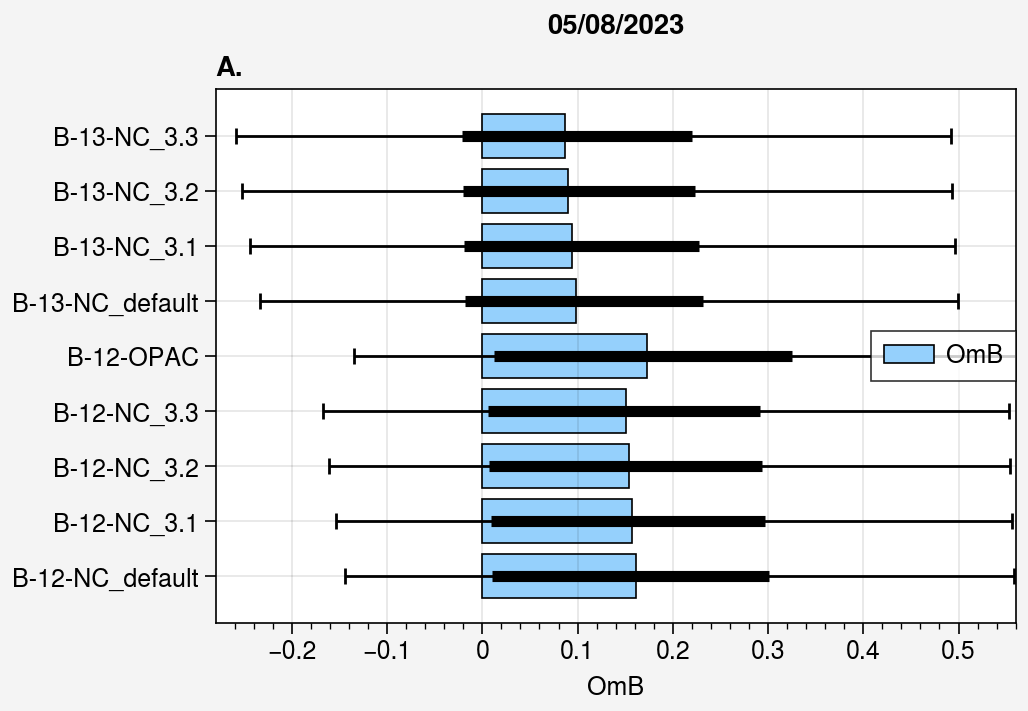

In [ ]:
import proplot as pplt
import numpy as np

# Loop through "vertical" and "horizontal" versions
varray = [[1], [2], [3]]
harray = [[1, 1]]
orientation = 'horizontal'
array = harray
if True:
    # Figure
    fig = pplt.figure(refwidth=4, refaspect=1.5, share=False)
    axs = fig.subplots(array)
    axs.format(abc='A.', suptitle=f'05/08/2023') # 05/08/2023 Whole August

    # Medians and percentile ranges
    ax = axs[0]
    kw = dict(
        color='light blue', edgecolor='k', legend=True,
        mean=True, barpctile=90, boxpctile=True,
        # median=True, barpctile=(5, 95), boxpctile=(25, 75)  # equivalent
    )
    if orientation == 'horizontal':
        ax.barh(data, **kw)
    else:
        ax.bar(data, **kw)
    #ax.format(title='Bar plot')
    ax.set_xlim(-0.28, 0.56)
    fig.savefig("/path/to/to_ucloud/bar_plot_day.png", dpi=1200)

### Plotting histograms using proplot library

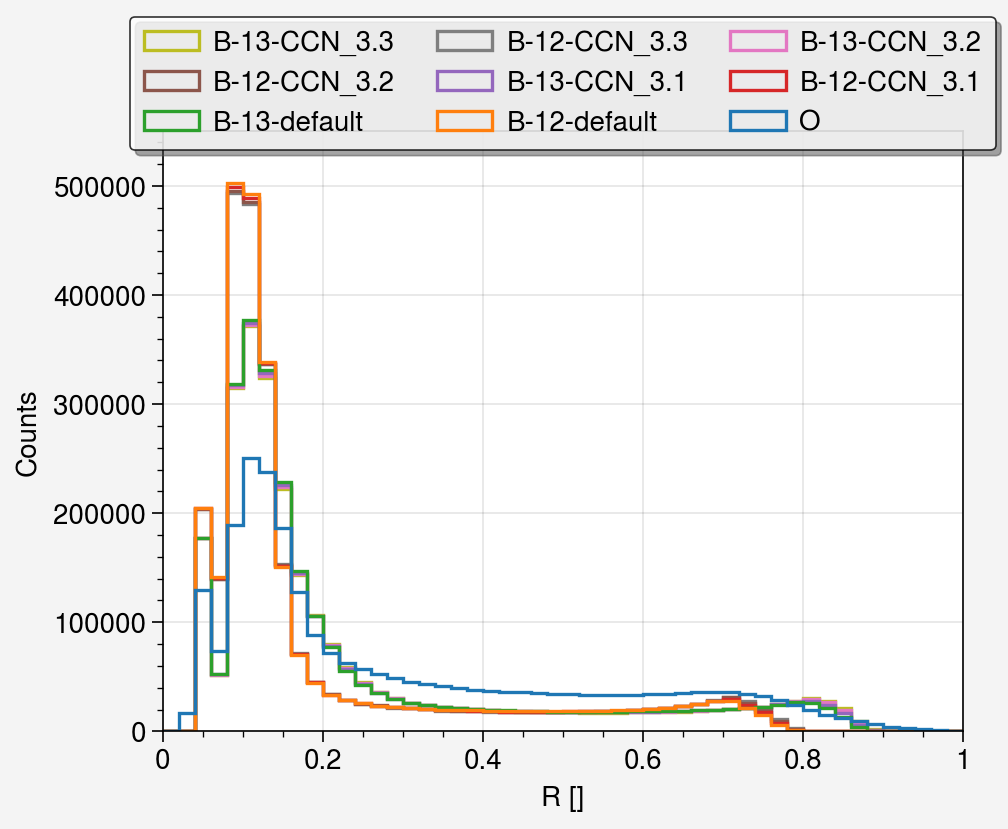

In [ ]:
fig, ax = plot_simulations(sims,columns=['O',"B-12-default","B-13-default",'B-12-CCN_3.1','B-13-CCN_3.1',
                                         'B-12-CCN_3.2', 'B-13-CCN_3.2',
                                         'B-12-CCN_3.3', 'B-13-CCN_3.3'],x_lims=(0,1),y_lims=(0,550000),
                     bins=50,
                     range_=(0,1),
                     colors=None,
                     alpha=1,
                     legend_loc='c',
                     title='',
                     xlabel='R []',
                     ylabel='Counts', log_x=False, log_y=False,save=True, name="/path/to/to_ucloud/results_CCN")

## Map: Snow and CCN effects

In [4]:
LON = rttov122["default"].data.lon_obs_map.values
LAT = rttov122["default"].data.lat_obs_map.values

date_time = "20230803_120000"
o = exp_results['default']["O"][date_time]
b13_default = exp_results['default']["B-rttov13"][date_time]
b13_CCN3_3 = exp_results['v3.3']["B-rttov13"][date_time]

b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

# --- your existing slice and data prep ---
r1, r2 = 80, 150
c1, c2 = 240, 300
x = LON[r1:r2, c1:c2]
y = LAT[r1:r2, c1:c2]
z_terrain = H[r1:r2, c1:c2] * 1000

p1 = o[r1:r2, c1:c2]
p2 = o[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p3 = b13_100[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p4 = b13_CCN3_3[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]

date_time = "20230805_120000"
o = exp_results['default']["O"][date_time]
b13_default = exp_results['default']["B-rttov13"][date_time]
b13_CCN3_3 = exp_results['v3.3']["B-rttov13"][date_time]

b13_100 = exp_results['v1.2']["B-rttov13"][date_time]

p5 = o[r1:r2, c1:c2]
p6 = o[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p7 = b13_100[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]
p8 = b13_CCN3_3[r1:r2, c1:c2] - b13_default[r1:r2, c1:c2]

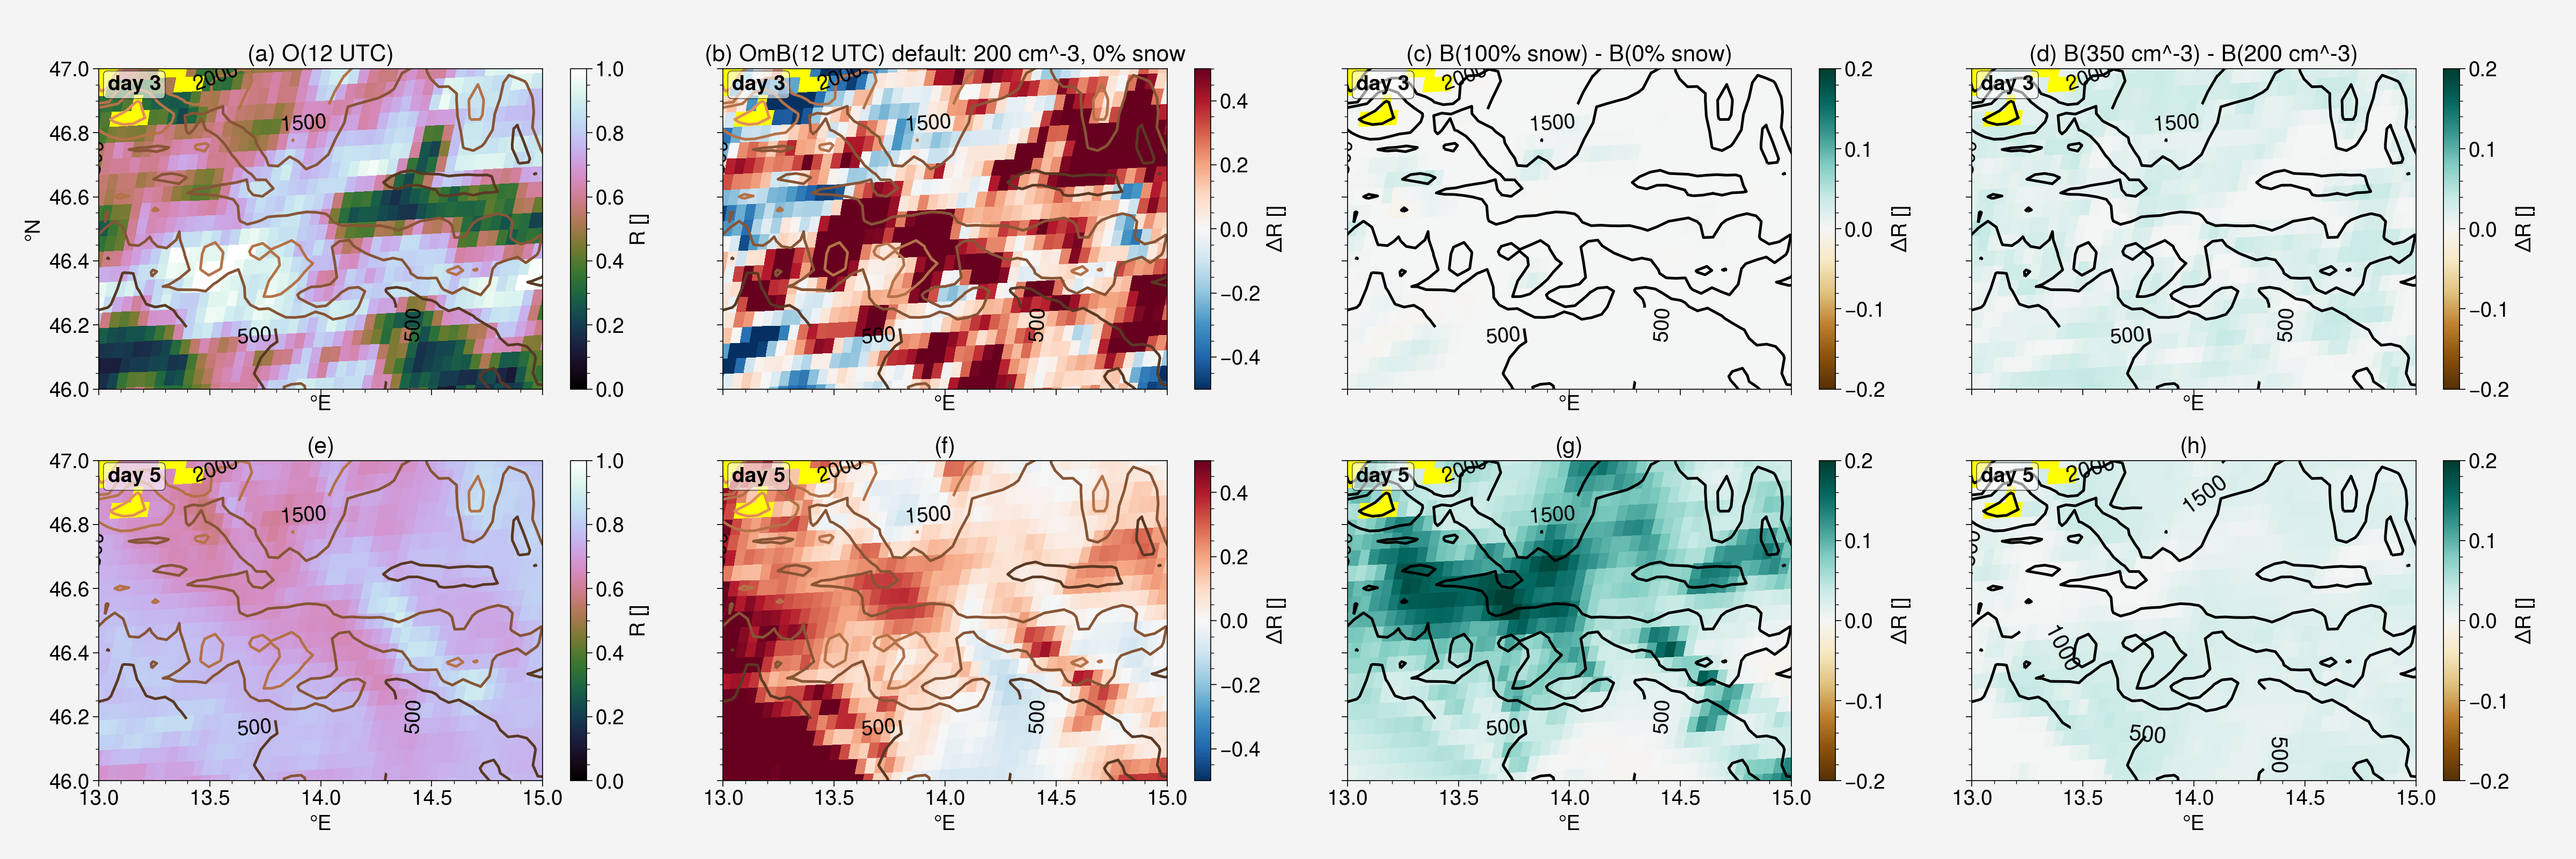

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

vmin, vmax = -0.2, 0.2
# --- create a 1×3 figure ---
fig, axees = plt.subplots(2, 4, figsize=(24, 8), sharex=True, sharey=True)
plt.rcParams.update({'font.size': 14})
axes = axees.flatten()

# common formatter for lon/lat
i = 0
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.set_xlim(13, 15)
    ax.set_ylim(46, 47)
    ax.set_xlabel("°E")
    if i > 3:
        ax.text(0.02, 0.98, f"day 5",
            transform=ax.transAxes,
            va='top', ha='left',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    elif i < 4:
        ax.text(0.02, 0.98, f"day 3",
            transform=ax.transAxes,
            va='top', ha='left',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
    i = i + 1
axes[0].set_ylabel("°N")

# --- panel 1: O difference ---
pcm1 = axes[0].pcolormesh(x, y, p1,
                          vmin=0, vmax=1,
                          cmap='cubehelix', shading='auto')
cbar1 = fig.colorbar(pcm1, ax=axes[0], label="R []")
cont1 = axes[0].contour(x, y, z_terrain,
                       levels=5, cmap="copper", linewidths=1.8)
axes[0].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')
axes[0].set_title("(a) O(12 UTC)")
axes[0].set_facecolor('yellow')

# --- panel 2: B difference ---
pcm2 = axes[1].pcolormesh(x, y, p2,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm2, ax=axes[1], label="ΔR []")
cont2 = axes[1].contour(x, y, z_terrain,
                       levels=5, cmap="copper",linewidths=1.8)
axes[1].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[1].set_title("(b) OmB(12 UTC) default: 200 cm^-3, 0% snow")
axes[1].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm3 = axes[2].pcolormesh(x, y, p3,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar3 = fig.colorbar(pcm3, ax=axes[2], label="ΔR []")
cont3 = axes[2].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[2].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[2].set_title("(c) B(100% snow) - B(0% snow)")
axes[2].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm4 = axes[3].pcolormesh(x, y, p4,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar4 = fig.colorbar(pcm4, ax=axes[3], label="ΔR []")
cbar4 = axes[3].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[3].clabel(cbar4, inline=True, fontsize=14, colors='black', fmt='%10.0f')
axes[3].set_title("(d) B(350 cm^-3) - B(200 cm^-3)")
axes[3].set_facecolor('yellow')

# --- panel 1: O difference ---
pcm5 = axes[4].pcolormesh(x, y, p5,
                          vmin=0, vmax=1,
                          cmap='cubehelix', shading='auto')
cbar1 = fig.colorbar(pcm5, ax=axes[4], label="R []")
cont1 = axes[4].contour(x, y, z_terrain,
                       levels=5, cmap="copper", linewidths=1.8)
axes[4].clabel(cont1, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[4].set_title("(e)")
axes[4].set_facecolor('yellow')
# --- panel 2: B difference ---
pcm6 = axes[5].pcolormesh(x, y, p6,
                          vmin=-0.5, vmax=0.5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm6, ax=axes[5], label="ΔR []")
cont2 = axes[5].contour(x, y, z_terrain,
                       levels=5, cmap="copper",linewidths=1.8)
axes[5].clabel(cont2, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[5].set_title("(f)")
axes[5].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm7 = axes[6].pcolormesh(x, y, p7,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar3 = fig.colorbar(pcm7, ax=axes[6], label="ΔR []")
cont3 = axes[6].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[6].clabel(cont3, inline=True, fontsize=14, colors='black', fmt='%10.0f')

axes[6].set_title("(g)")
axes[6].set_facecolor('yellow')
# --- panel 3: terrain ---
pcm8 = axes[7].pcolormesh(x, y, p8,
                          vmin=vmin, vmax=vmax,
                          cmap='BrBG', shading='auto')
cbar8 = fig.colorbar(pcm8, ax=axes[7], label="ΔR []")
cbar8 = axes[7].contour(x, y, z_terrain,
                       levels=5, colors="black", linewidths=1.8)
axes[7].clabel(cbar8, inline=True, fontsize=15, colors='black', fmt='%10.0f')

axes[7].set_title("(h)")
axes[7].set_facecolor('yellow')

# --- layout & save ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("/path/to/to_ucloud/CCN&snow_effects.png", dpi=1200)
plt.show()

## Sensitivity tests common histogram

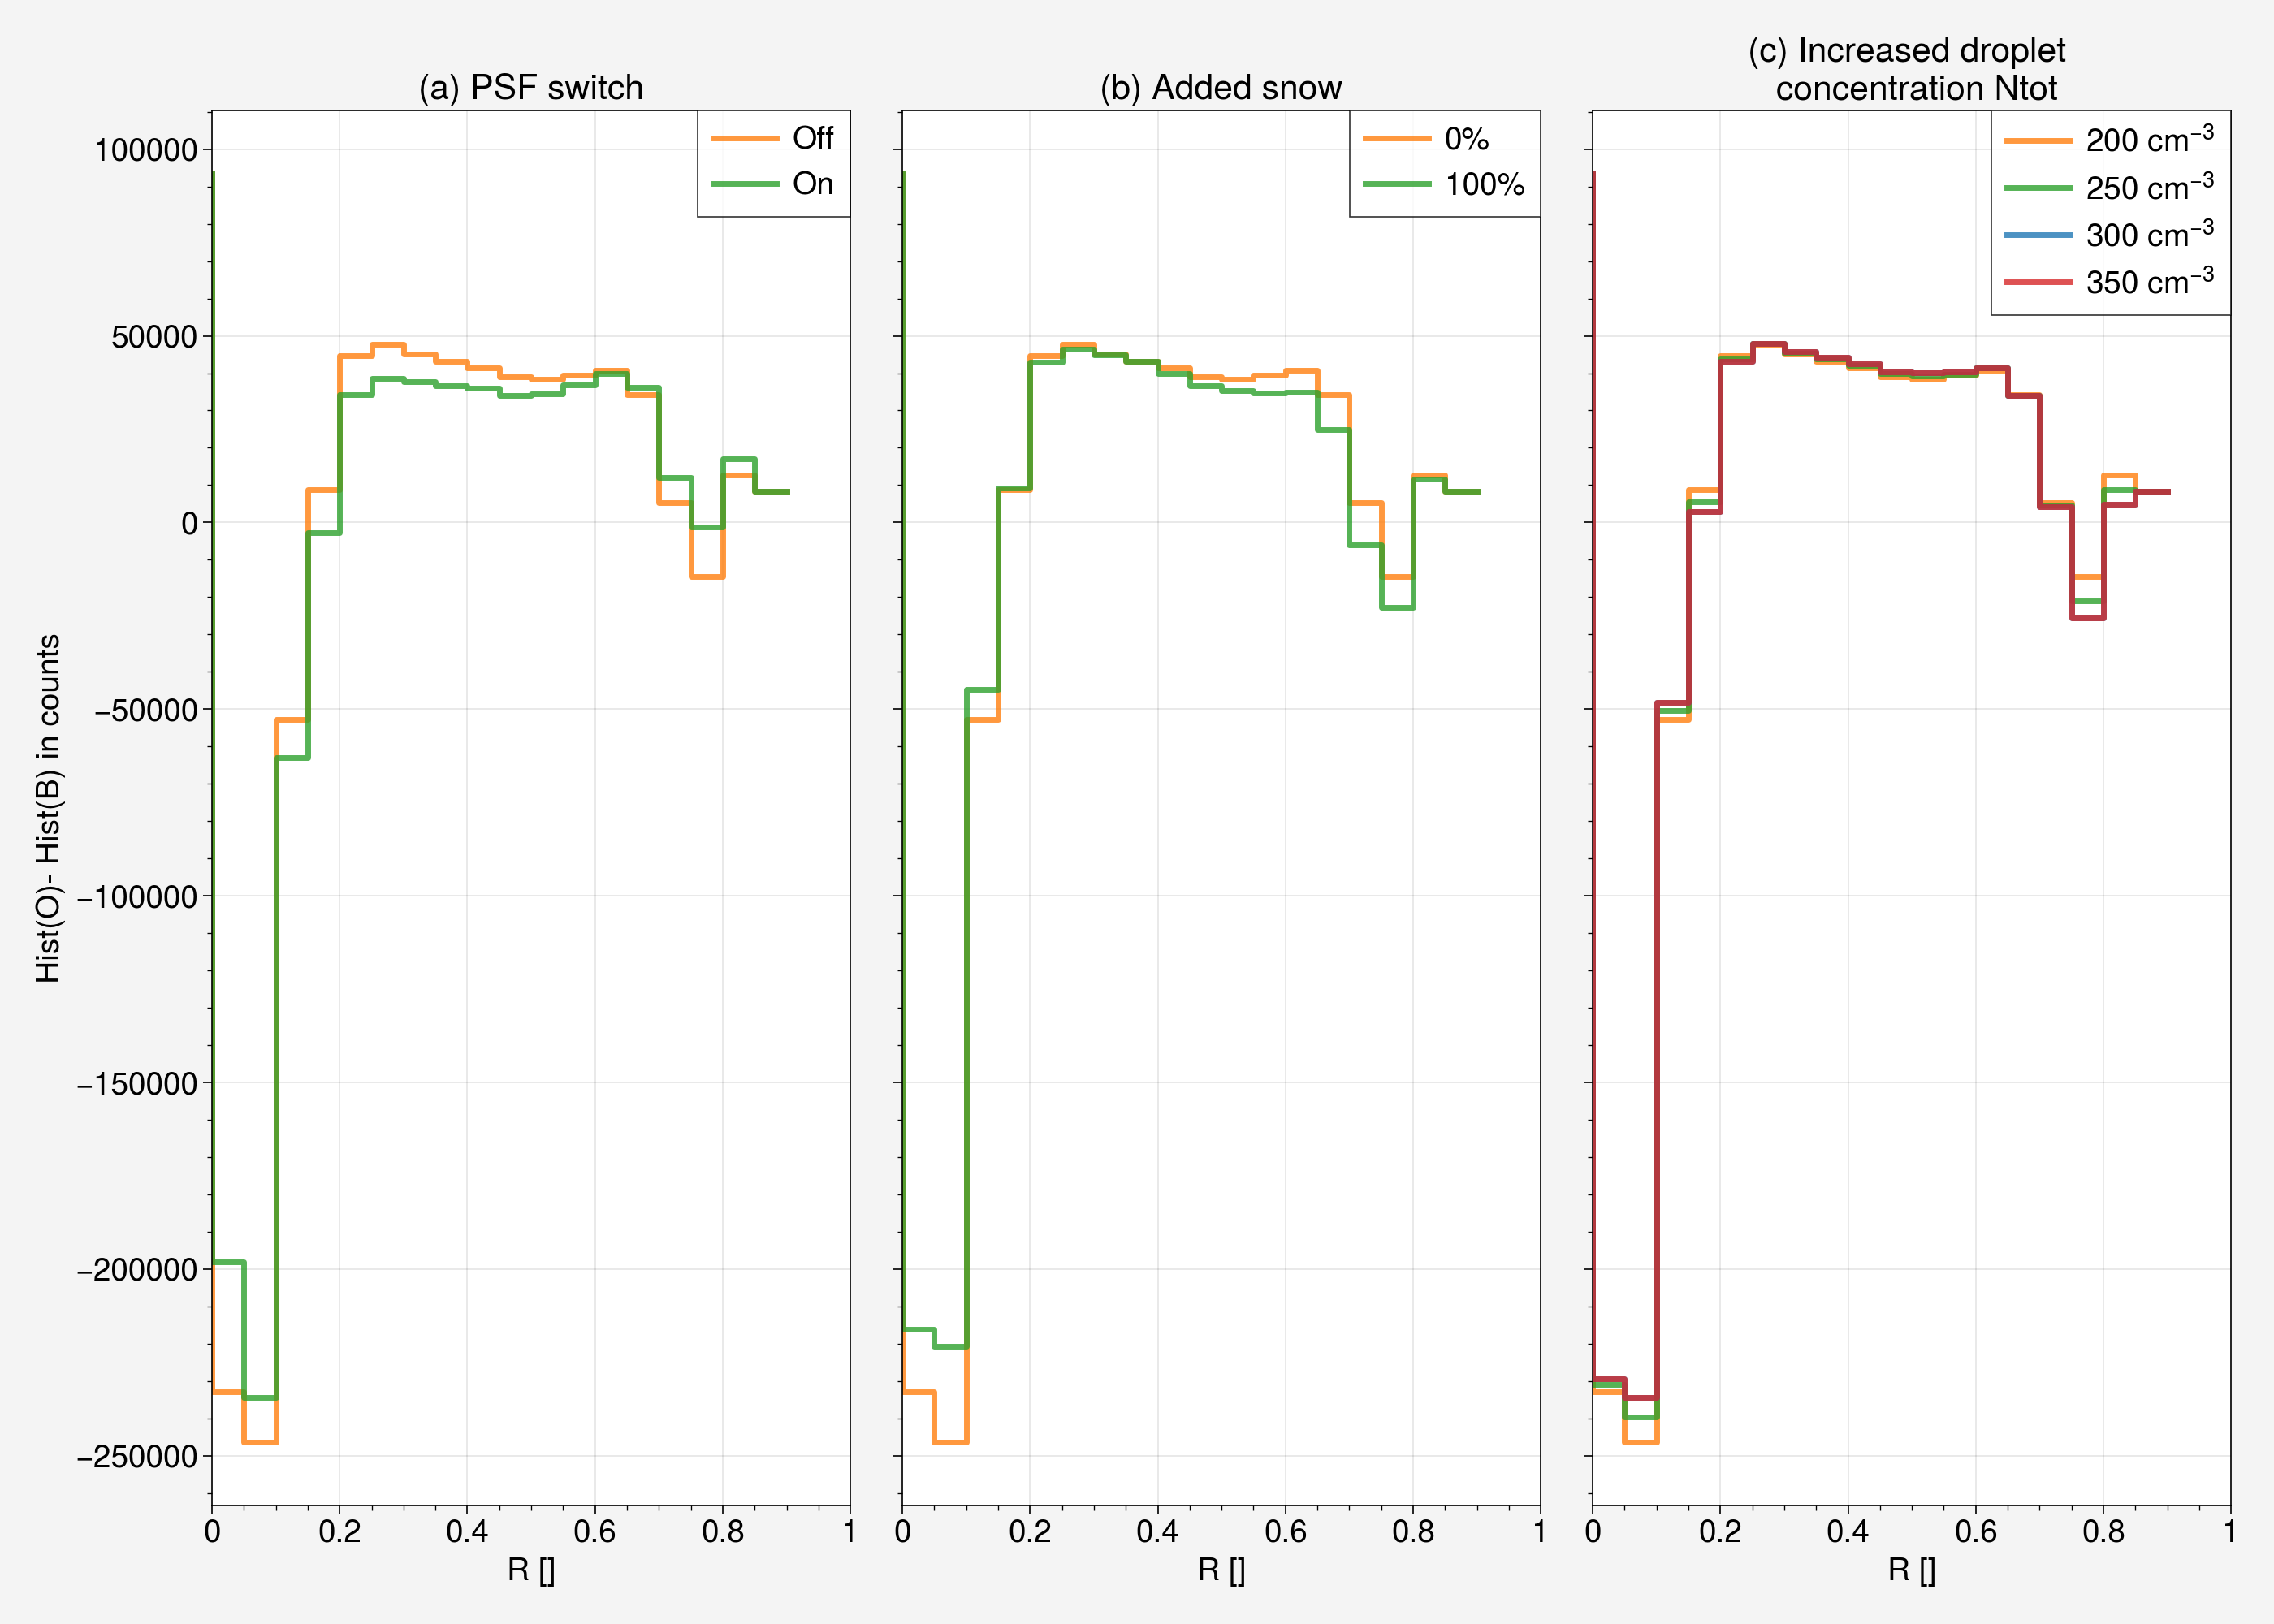

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# sample data
np.random.seed(2024)
lw= 2.5
# dataframe from sample distributions
df = pd.DataFrame({'O': sims_psf["O"], 'psf_on': sims_psf["B-psf=on"], 'psf_off': sims_psf["B-psf=off"],
                 'snow':sims_snow["B-13-100%"], 'nosnow':sims_snow["B-13-default"],
                 'CCN_def':sims["B-13-default"], 'CCN_1':sims["B-13-CCN_3.1"],'CCN_2':sims["B-13-CCN_3.2"],
                 'CCN_3':sims["B-13-CCN_3.3"]},)

# calculate the histogram for each distribution
bin_edges = np.arange(0, 1, 0.05)

a_hist, _ = np.histogram(df.O, bins=bin_edges) 
b_hist, _ = np.histogram(df.psf_off, bins=bin_edges) 
c_hist, _ = np.histogram(df.psf_on, bins=bin_edges)

# calculate the difference
h_diff_i = a_hist - b_hist # psf off
h_diff_ii = a_hist - c_hist # psf on

# plot
fig, axs = plt.subplots(1, 3, figsize=(14, 10))
sns.lineplot(x=bin_edges[:-1], y=h_diff_i, color='tab:orange', drawstyle='steps-pre' ,alpha=0.8,lw=lw, ax=axs[0], label='Off')
sns.lineplot(x=bin_edges[:-1], y=h_diff_ii, color='tab:green',  drawstyle='steps-pre', alpha=0.8, lw=lw, ax=axs[0], label='On')

#ax.set_xticks(ticks=np.arange(0, 9)-0.5, labels=bin_edges)
axs[0].margins(x=0.1)
_ = axs[0].set(title='(a) PSF switch', ylabel='Hist(O)- Hist(B) in counts', xlabel='R []')

# Snow effects 

 
b_hist, _ = np.histogram(df.nosnow, bins=bin_edges) 
c_hist, _ = np.histogram(df.snow, bins=bin_edges)

# calculate the difference
h_diff_i = a_hist - b_hist
h_diff_ii = a_hist - c_hist

sns.lineplot(x=bin_edges[:-1], y=h_diff_i, color='tab:orange', drawstyle='steps-pre', alpha=0.8, lw=lw, ax=axs[1], label='0%')
sns.lineplot(x=bin_edges[:-1], y=h_diff_ii, color='tab:green', drawstyle='steps-pre', alpha=0.8,lw=lw, ax=axs[1], label='100%')

#ax.set_xticks(ticks=np.arange(0, 9)-0.5, labels=bin_edges)
axs[1].margins(x=0.1)
_ = axs[1].set(title='(b) Added snow', xlabel='R []')
axs[1].set_yticklabels([])

# CCN effects 

b_hist, _ = np.histogram(df.CCN_def, bins=bin_edges) 
c_hist, _ = np.histogram(df.CCN_1, bins=bin_edges)
d_hist, _ = np.histogram(df.CCN_2, bins=bin_edges) 
e_hist, _ = np.histogram(df.CCN_3, bins=bin_edges) 

# calculate the difference
h_diff_i = a_hist - b_hist
h_diff_ii = a_hist - c_hist
h_diff_iii = a_hist - d_hist
h_diff_vi = a_hist - d_hist

sns.lineplot(x=bin_edges[:-1], y=h_diff_i, color='tab:orange', drawstyle='steps-pre', alpha=0.8,lw=lw, ax=axs[2], label=r"$200\ \mathrm{cm}^{-3}$")
sns.lineplot(x=bin_edges[:-1], y=h_diff_ii, color='tab:green', drawstyle='steps-pre', alpha=0.8,lw=lw,ax=axs[2], label=r"$250\ \mathrm{cm}^{-3}$")
sns.lineplot(x=bin_edges[:-1], y=h_diff_iii, color='tab:blue', drawstyle='steps-pre', alpha=0.8,lw=lw, ax=axs[2], label=r"$300\ \mathrm{cm}^{-3}$")
sns.lineplot(x=bin_edges[:-1], y=h_diff_iii, color='tab:red', drawstyle='steps-pre', alpha=0.8,lw=lw, ax=axs[2], label=r"$350\ \mathrm{cm}^{-3}$")

#ax.set_xticks(ticks=np.arange(0, 9)-0.5, labels=bin_edges)
axs[2].margins(x=0.1)
_ = axs[2].set(title=f'(c) Increased droplet \n concentration Ntot', xlabel='R []')
axs[2].set_yticklabels([])
axs[0].set_xlim(0,1)
axs[1].set_xlim(0,1)
axs[2].set_xlim(0,1)

plt.tight_layout()
plt.savefig("/path/to/to_ucloud/R_hist_merged_tests_12utc.png", dpi=300)
plt.show()

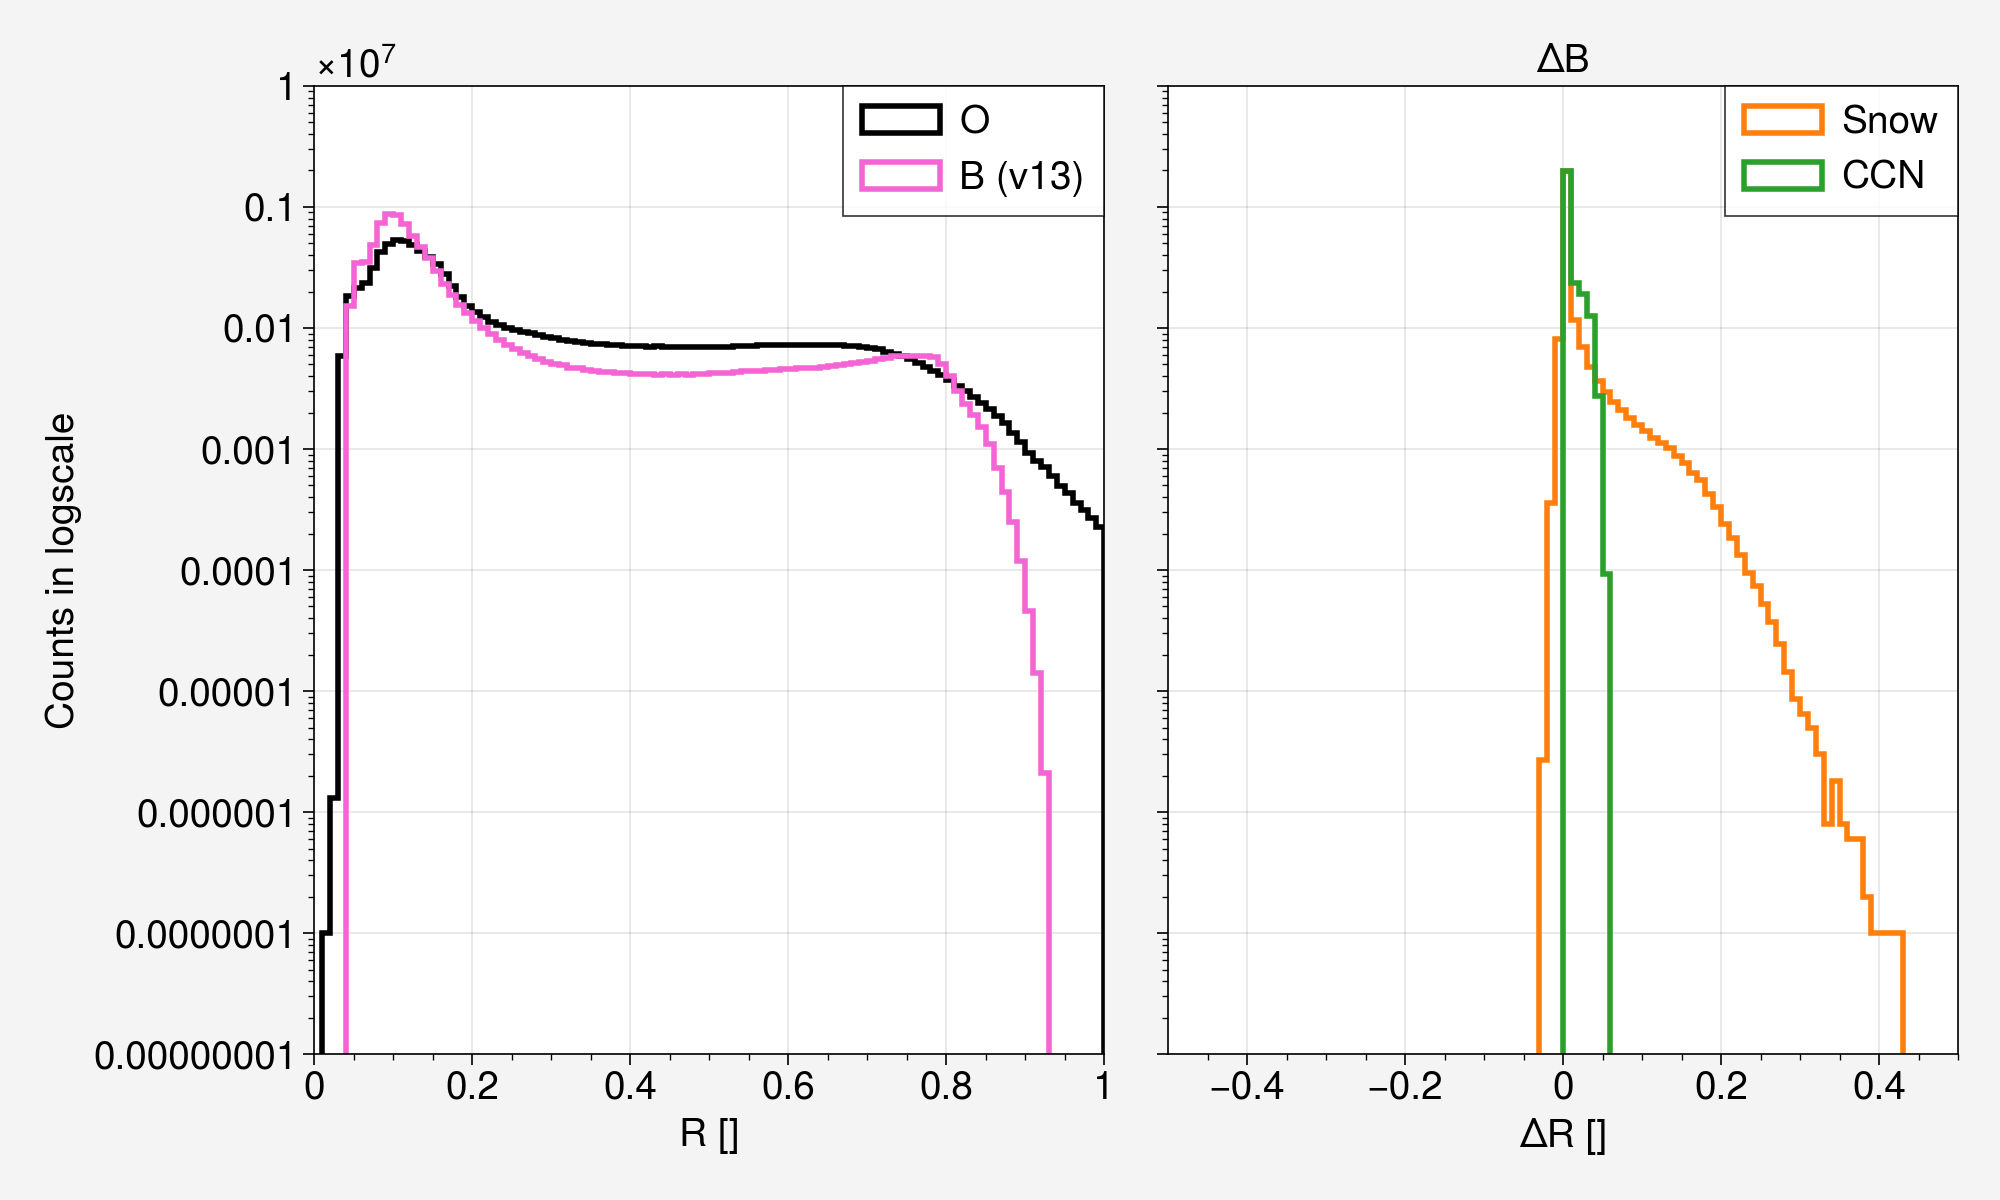

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = 100
range_ = (0, 1)
log_scale = True

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.rcParams.update({"font.size":14})
fig.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.0, hspace=0.0)

axs = axs.flatten()  # makes indexing easier

# first plot
axs[0].hist(flatten_array(ref["O"]), bins=100, 
              log=log_scale,histtype='step', color = 'black',range= range_, lw=2, label = 'O');
axs[0].hist(flatten_array(ref["B-rttov13"]), bins=100, 
              log=log_scale,histtype='step', color = '#f564d4',range= range_, lw=2, label = 'B (v13)');
axs[0].set_title("", fontsize=14)
axs[0].set_xlabel("R []", fontsize=14)
axs[0].set_xlim(0,1)
axs[0].set_ylim(10.e-2,1.e7)
axs[0].set_ylabel("Counts in logscale", fontsize=14)
axs[0].legend(fontsize=14)
axs[0].margins(x=0.1)

bins = 100
range_ = (-0.5, 0.5)
log_scale = True

# second plot
axs[1].hist(sims_snow["B-13-100%"]-sims_snow["B-13-default"], bins=100, 
              log=log_scale,histtype='step', color = 'tab:orange',range= range_, lw=2, label = 'Snow');
axs[1].hist(sims["B-13-CCN_3.3"]-sims["B-13-default"], bins=100, 
              log=log_scale,histtype='step', color = 'tab:green',range= range_, lw=2, label = 'CCN');
axs[1].set_title("ΔB", fontsize=14)
axs[1].set_xlabel("ΔR []", fontsize=14)
axs[1].set_ylim(10.e-2,1.e7)
axs[1].set_xlim(-0.5, 0.5)
axs[1].legend(fontsize=14)
axs[1].set_yticklabels([])
axs[1].margins(x=0.1)

plt.tight_layout()
plt.savefig("path/to/to_ucloud/B_hist_all_sky_12utc.png", dpi=300)
plt.show()

## statistics

In [83]:
import numpy as np
import pandas as pd

def compute_error_stats(a,b,percentiles):
    """
    Compute summary statistics for absolute and relative errors between arrays a and b.

    Returns a DataFrame with two columns: 'Absolute Error' and 'Relative Error'.
    """
    # Compute errors
    abs_err = a - b
    rel_err = abs_err / b

    # Helper to build a stats dict for a given error array
    def stats_dict(err: np.ndarray, name: str) -> pd.Series:
        d = {
            'RMSE'        : np.sqrt(np.mean(err**2)),
            'Std'         : np.std(err),
            'Min'         : np.min(err),
            'Max'         : np.max(err),
            'Mean'        : np.mean(err),
        }
        # add percentiles
        for p in percentiles:
            d[f'{p}th pct'] = np.percentile(err, p)
        return pd.Series(d, name=name)

    # Build DataFrame
    df_abs = stats_dict(abs_err, 'Absolute Error')
    df_rel = stats_dict(rel_err, 'Relative Error')

    return pd.concat([df_abs, df_rel], axis=1)

In [106]:
import numpy as np

def f1(a, threshold):
    """
    Return the percentage of elements in `a` that exceed `threshold`.
    
    Parameters
    ----------
    a : array‑like
        Input data.
    threshold : float
        Threshold value.
    
    Returns
    -------
    float
        Percentage of elements > threshold.
    """
    arr = np.asarray(a)
    count_above = np.sum(arr < threshold)
    total_elems = arr.size
    return count_above / total_elems * 100

In [ ]:
df = pd.DataFrame({'O': sims_psf["O"], 'psf_on': sims_psf["B-psf=on"], 'psf_off': sims_psf["B-psf=off"],
                 'snow':sims_snow["B-13-100%"], 'nosnow':sims_snow["B-13-default"],
                 'CCN_def':sims["B-13-default"], 'CCN_1':sims["B-13-CCN_3.1"],'CCN_2':sims["B-13-CCN_3.2"],
                 'CCN_3':sims["B-13-CCN_3.3"]},)

In [105]:
print(f1(sims_psf["B-psf=on"], 0.6) - f1(sims_psf["B-psf=off"], 0.6))
print(f1(sims_snow["B-13-100%"], 0.6) - f1(sims_psf["B-psf=off"], 0.6))
print(f1(sims["B-13-CCN_3.3"], 0.6) - f1(sims_psf["B-psf=off"], 0.6))

-0.8894048946647057
1.6045403285541422
0.9879578196614638


In [107]:
print(f1(sims_psf["B-psf=on"], 0.15) - f1(sims_psf["B-psf=off"], 0.15))
print(f1(sims_snow["B-13-100%"], 0.15) - f1(sims_psf["B-psf=off"], 0.15))
print(f1(sims["B-13-CCN_3.3"], 0.15) - f1(sims_psf["B-psf=off"], 0.15))

-1.8366254162353073
-1.668505720652604
-0.8283772884862728


In [84]:
# Example usage:
if __name__ == "__main__":
    # dummy data
    a = np.random.rand(1000) * 10
    b = np.random.rand(1000) * 10 + 1e-3  # avoid zero division
    df = compute_error_stats(a, b, [95,99])
    print(df)

          Absolute Error  Relative Error
RMSE            4.146955       37.023952
Std             4.144477       36.728337
Min            -9.764548       -0.994846
Max             9.689063      774.626983
Mean            0.143355        4.669288
95th pct        7.052460       10.861712
99th pct        8.735693      112.555635


In [86]:
df = compute_error_stats(sims_psf["O"], sims_psf["B-psf=off"], [95,99])
df

,Absolute Error,Relative Error
RMSE,0.197354,1.265536
Std,0.186165,1.151193
Min,-0.840458,-0.950465
Max,1.080154,16.798400
Mean,0.065507,0.525677
95th pct,0.431927,2.831228
99th pct,0.625255,5.248399


In [87]:
df = compute_error_stats(sims_psf["O"], sims_psf["B-psf=on"], [95,99])
df

,Absolute Error,Relative Error
RMSE,0.190206,1.180933
Std,0.178538,1.077261
Min,-0.812473,-0.949017
Max,1.078145,16.798400
Mean,0.065592,0.483849
95th pct,0.421038,2.609124
99th pct,0.613238,4.891449


In [88]:
df = compute_error_stats(sims_psf["O"], sims_snow["B-13-100%"], [95,99])
df

,Absolute Error,Relative Error
RMSE,0.192784,1.208458
Std,0.185046,1.113458
Min,-0.841142,-0.950511
Max,1.080154,16.798400
Mean,0.054073,0.469662
95th pct,0.414213,2.680221
99th pct,0.615987,5.097337


In [89]:
df = compute_error_stats(sims_psf["O"], sims["B-13-CCN_3.3"], [95,99])
df

,Absolute Error,Relative Error
RMSE,0.197628,1.242806
Std,0.188635,1.137522
Min,-0.852671,-0.951792
Max,1.080154,16.798400
Mean,0.058938,0.500611
95th pct,0.425960,2.767527
99th pct,0.621582,5.195646
